# Spaceship Titanic Dataset with TensorFlow Decision Forests

# Import the library

In [261]:
import tensorflow as tf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import layers, models
from sklearn.model_selection import KFold
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.optimizers import Adam

# Load the Dataset

In [262]:
# Load a dataset into a Pandas Dataframe
df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
print("Full train dataset shape is {}".format(df.shape))
print("Full test dataset shape is {}".format(test_df.shape))

Full train dataset shape is (8693, 14)
Full test dataset shape is (4277, 13)


# Prepare the dataset

We will drop both `PassengerId` and `Name` columns as they are not necessary for model training.

In [263]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [264]:
# GroupSize: cuántos pasajeros viajan en la misma reserva
df['Group']     = df['PassengerId'].str.split('_').str[0]
df['GroupSize'] = df.groupby('Group')['Group'].transform('count')
df['IsAlone']   = (df['GroupSize'] == 1).astype(int)
 
# FamilySize: mismo apellido dentro del mismo grupo → familia
df['Surname']    = df['Name'].str.split().str[-1].fillna('Unknown')
df['FamilyKey']  = df['Group'] + '_' + df['Surname']
df['FamilySize'] = df.groupby('FamilyKey')['FamilyKey'].transform('count')
df['IsWithFamily'] = (df['FamilySize'] > 1).astype(int)

In [265]:
# Limpiar columnas auxiliares
df = df.drop(['Group', 'Surname', 'FamilyKey'], axis=1)
 
df = df.drop(['PassengerId', 'Name'], axis=1)
df.head(5)

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,GroupSize,IsAlone,FamilySize,IsWithFamily
0,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,1,1,1,0
1,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,1,1,1,0
2,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,2,0,2,1
3,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,2,0,2,1
4,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,1,1,1,0


We will check for the missing values using the following code:

In [266]:
df.isnull().sum().sort_values(ascending=False)

CryoSleep       217
ShoppingMall    208
VIP             203
HomePlanet      201
Cabin           199
VRDeck          188
FoodCourt       183
Spa             183
Destination     182
RoomService     181
Age             179
Transported       0
GroupSize         0
IsAlone           0
FamilySize        0
IsWithFamily      0
dtype: int64

This dataset contains a mix of numeric, categorical and missing features. TF-DF supports all these feature types natively, and no preprocessing is required.

But this datatset also has boolean fields with missing values. TF-DF doesn't support boolean fields yet. So we need to convert those fields into int. To account for the missing values in the boolean fields, we will replace them with zero.

In this notebook, we will replace null value entries with zero for numerical columns as well and only let TF-DF handle the missing values in categorical columns.

Note: You can choose to let TF-DF handle missing values in numerical columns if need be.

In [267]:
df[['VIP', 'CryoSleep', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']] = df[['VIP', 'CryoSleep', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']].fillna(value=0)
df.isnull().sum().sort_values(ascending=False)

HomePlanet      201
Cabin           199
Destination     182
RoomService     181
Age             179
CryoSleep         0
VIP               0
FoodCourt         0
ShoppingMall      0
Spa               0
VRDeck            0
Transported       0
GroupSize         0
IsAlone           0
FamilySize        0
IsWithFamily      0
dtype: int64

Since, TF-DF cannot handle boolean columns, we will have to adjust the labels in column `Transported` to convert them into the integer format that TF-DF expects.

In [268]:
label = "Transported"
df[label] = df[label].astype(int)

We will also convert the boolean fields `CryoSleep` and `VIP` to int.

In [269]:
df['VIP'] = df['VIP'].astype(int)


The value of column `Cabin` is a string with the format `Deck/Cabin_num/Side`. Here we will split the `Cabin` column and create 3 new columns `Deck`, `Cabin_num` and `Side`, since it will be easier to train the model on those individual data.

Run the following command to split the column `Cabin` into columns `Deck`, `Cabin_num` and `Side`

In [270]:
df[["Deck", "Cabin_num", "Side"]] = df["Cabin"].str.split("/", expand=True)

Remove original `Cabin` column from the dataset since it's not needed anymore.

In [271]:
try:
    df = df.drop('Cabin', axis=1)
except KeyError:
    print("Field does not exist")

In [272]:
columnas_num = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Cabin_num']

for col in columnas_num:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Tratamos numéricos con la mediana
for col in columnas_num:
    df[col] = df[col].fillna(df[col].median())

In [273]:
# ── FEATURE ENGINEERING 2/3: corrección CryoSleep/gasto ─────────────────────
# Si alguien está en CryoSleep no puede gastar → ponemos sus gastos a 0
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
cryo_bool = df['CryoSleep'].astype(str).str.lower().isin(['true', '1.0', '1'])
df.loc[cryo_bool, spend_cols] = 0
# Si tiene gastos > 0 → CryoSleep debe ser False
has_spend_mask = df[spend_cols].sum(axis=1) > 0
df.loc[has_spend_mask, 'CryoSleep'] = 'False'

In [274]:
# ── FEATURE ENGINEERING 3/3: nuevas variables ────────────────────────────────
 
# 1. Agregados de gasto
df['TotalSpend']    = df[spend_cols].sum(axis=1)
df['LuxurySpend']   = df[['Spa', 'VRDeck']].sum(axis=1)
df['BasicSpend']    = df[['RoomService', 'FoodCourt', 'ShoppingMall']].sum(axis=1)
df['HasSpend']      = (df['TotalSpend'] > 0).astype(int)
df['SpendDiversity']= (df[spend_cols] > 0).sum(axis=1)

In [275]:
# 2. Log1p en columnas de gasto (reducir skewness de 6-12 → ~1)
for col in spend_cols + ['TotalSpend', 'LuxurySpend', 'BasicSpend']:
    df[col] = np.log1p(df[col])

In [276]:
# 3. Variables de edad
df['IsChild']  = (df['Age'] < 13).astype(float)
df['AgeGroup'] = pd.cut(df['Age'],
                    bins=[-1, 12, 17, 35, 60, 80],
                    labels=[0, 1, 2, 3, 4]).astype(float)

In [277]:
# 4. Deck codificado por tasa real de transporte (evita one-hot de alta cardinalidad)
deck_rate = {'B': 0.73, 'C': 0.68, 'G': 0.52,
             'A': 0.50, 'F': 0.44, 'D': 0.43,
             'E': 0.36, 'T': 0.20}
df['DeckEncoded'] = df['Deck'].map(deck_rate).fillna(0.5)

In [278]:
# Tratamos categóricos con la moda
columnas_cat = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']
for col in columnas_cat:
    # Es importante asegurar que la columna sea tratada como string para la moda
    df[col] = df[col].astype(str)
    moda = df[col].mode()[0]
    df[col] = df[col].fillna(moda)

In [279]:
# Aplicar One-Hot Encoding a las columnas categóricas
df = pd.get_dummies(df, columns=columnas_cat, drop_first=False)
df = df.astype(float)

# Verificar el resultado
print(df.head())

    Age  RoomService  FoodCourt  ShoppingMall       Spa    VRDeck  \
0  39.0     0.000000   0.000000      0.000000  0.000000  0.000000   
1  24.0     4.700480   2.302585      3.258097  6.309918  3.806662   
2  58.0     3.784190   8.182280      0.000000  8.812248  3.912023   
3  33.0     0.000000   7.157735      5.918894  8.110728  5.267858   
4  16.0     5.717028   4.262680      5.023881  6.338594  1.098612   

   Transported  GroupSize  IsAlone  FamilySize  ...  Deck_A  Deck_B  Deck_C  \
0          0.0        1.0      1.0         1.0  ...     0.0     1.0     0.0   
1          1.0        1.0      1.0         1.0  ...     0.0     0.0     0.0   
2          0.0        2.0      0.0         2.0  ...     1.0     0.0     0.0   
3          0.0        2.0      0.0         2.0  ...     1.0     0.0     0.0   
4          1.0        1.0      1.0         1.0  ...     0.0     0.0     0.0   

   Deck_D  Deck_E  Deck_F  Deck_G  Deck_T  Side_P  Side_S  
0     0.0     0.0     0.0     0.0     0.0     1.0 

In [280]:
def split_dataset_70_20_10(dataset):
    train_ds, temp_ds = train_test_split(dataset, test_size=0.30, random_state=42)
    valid_ds, test_ds = train_test_split(temp_ds, test_size=(1/3), random_state=42)
    return train_ds, valid_ds, test_ds



In [281]:
train_ds_pd, valid_ds_pd, test_ds_pd = split_dataset_70_20_10(df)


In [282]:
print("Train dataset shape is {}".format(train_ds_pd.shape))
print("Validation dataset shape is {}".format(valid_ds_pd.shape))   
print("Test dataset shape is {}".format(test_ds_pd.shape))


Train dataset shape is (6085, 41)
Validation dataset shape is (1738, 41)
Test dataset shape is (870, 41)


In [283]:
X_train = train_ds_pd.drop('Transported', axis=1).values
y_train = train_ds_pd['Transported'].values

X_valid = valid_ds_pd.drop('Transported', axis=1).values
y_valid = valid_ds_pd['Transported'].values

X_test = test_ds_pd.drop('Transported', axis=1).values
y_test = test_ds_pd['Transported'].values

In [284]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

In [285]:
input_shape = X_train.shape[1]
BATCH_SIZE  = 32
EPOCHS      = 50

RELU

In [286]:
def build_model_p1(input_dim):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
 
        # Capa 1: Dense → BN → ReLU
        layers.Dense(128),
        layers.BatchNormalization(),
        layers.Activation('relu'),
 
        # Capa 2: Dense → BN → ReLU
        layers.Dense(64),
        layers.BatchNormalization(),
        layers.Activation('relu'),
 
        # Capa 3: Dense → BN → ReLU
        layers.Dense(32),
        layers.BatchNormalization(),
        layers.Activation('relu'),
 
        layers.Dense(1, activation='sigmoid')
    ], name='Modelo_ReLU_BN')
 
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [287]:
model_p1 = build_model_p1(input_shape)


In [288]:
history_p1 = model_p1.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_valid, y_valid),
    callbacks=[EarlyStopping(monitor='val_loss', patience=8,
                             restore_best_weights=True, verbose=0)],
    verbose=0
)
print(f'Mejor val_accuracy: {max(history_p1.history["val_accuracy"]):.4f}')

Mejor val_accuracy: 0.7963


In [289]:
def plot_history(history, title):
    acc     = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss    = history.history['loss']
    val_loss= history.history['val_loss']
    ep      = range(1, len(acc) + 1)
 
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')
 
    axes[0].plot(ep, acc,     color='steelblue',  label='Train')
    axes[0].plot(ep, val_acc, color='darkorange', label='Validación', linestyle='--')
    axes[0].set_title('Accuracy'); axes[0].set_xlabel('Época')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
 
    axes[1].plot(ep, loss,     color='steelblue',  label='Train')
    axes[1].plot(ep, val_loss, color='darkorange', label='Validación', linestyle='--')
    axes[1].set_title('Loss'); axes[1].set_xlabel('Época')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
 
    plt.tight_layout()
    plt.show()

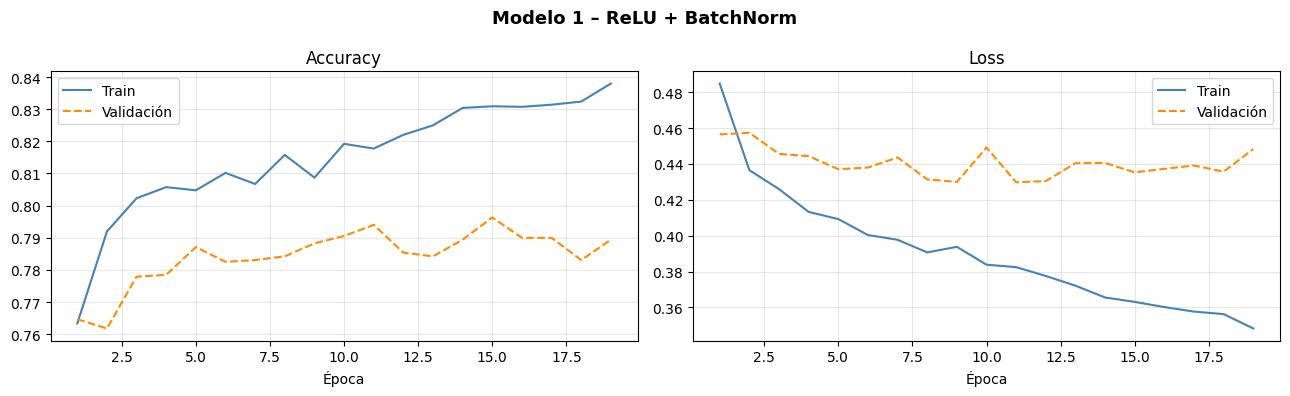

In [290]:
plot_history(history_p1, 'Modelo 1 – ReLU + BatchNorm')

LEAKY RELU

In [291]:
def build_model_p2(input_dim):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
 
        # Capa 1: Dense → BN → Leaky ReLU
        layers.Dense(128),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.1),
 
        # Capa 2: Dense → BN → Leaky ReLU
        layers.Dense(64),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.1),
 
        # Capa 3: Dense → BN → Leaky ReLU
        layers.Dense(32),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.1),
 
        layers.Dense(1, activation='sigmoid')
    ], name='Modelo_LeakyReLU_BN')
 
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [292]:
model_p2 = build_model_p2(input_shape)


In [293]:
history_p2 = model_p2.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_valid, y_valid),
    callbacks=[EarlyStopping(monitor='val_loss', patience=8,
                             restore_best_weights=True, verbose=0)],
    verbose=0
)

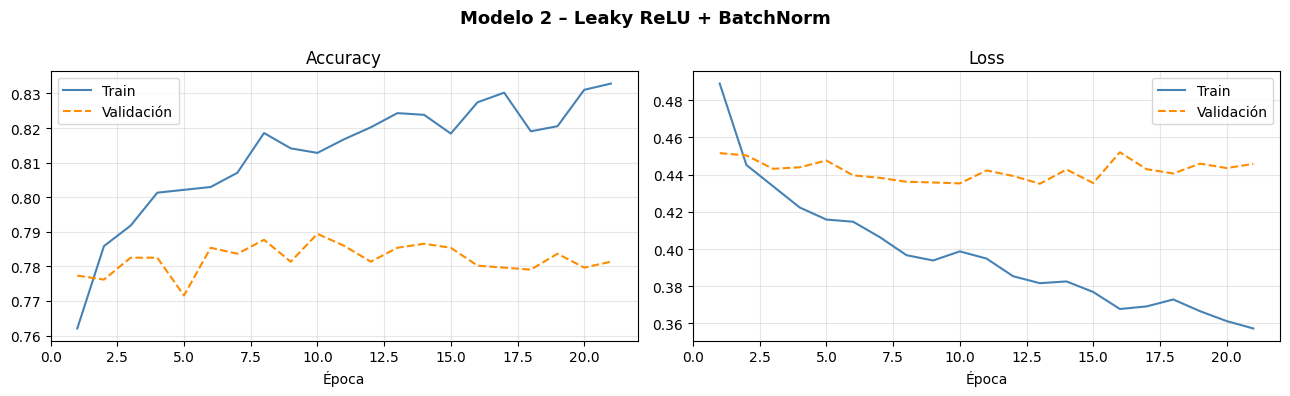

In [294]:
plot_history(history_p2, 'Modelo 2 – Leaky ReLU + BatchNorm')

RELU + LEAKY RELU + BATCHNORM

In [295]:
def build_model_p3(input_dim):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
 
        # Capa 1: Dense → Leaky ReLU → Dropout
        layers.Dense(128),
        layers.LeakyReLU(0.1),
        layers.Dropout(0.3),      # ← Dropout 1
 
        # Capa 2: Dense → Leaky ReLU → Dropout
        layers.Dense(64),
        layers.LeakyReLU(0.1),
        layers.Dropout(0.3),      # ← Dropout 2
 
        # Capa 3: Dense → Leaky ReLU
        layers.Dense(32),
        layers.LeakyReLU(0.1),
 
        layers.Dense(1, activation='sigmoid')
    ], name='Modelo_LeakyReLU_Dropout')
 
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [296]:
model_p3 = build_model_p3(input_shape)

In [297]:
history_p3 = model_p3.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_valid, y_valid),
    callbacks=[EarlyStopping(monitor='val_loss', patience=8,
                             restore_best_weights=True, verbose=0)],
    verbose=0
)

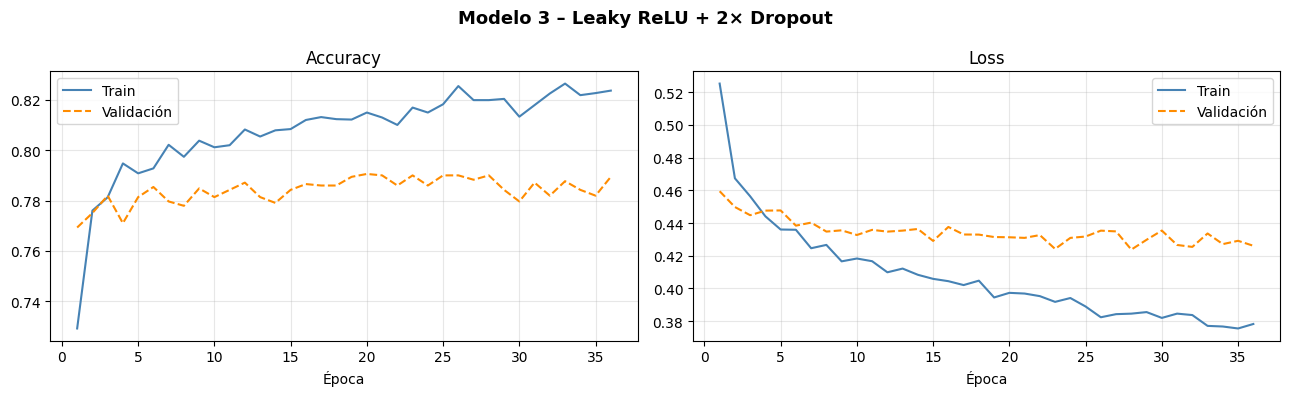

In [298]:
plot_history(history_p3, 'Modelo 3 – Leaky ReLU + 2× Dropout')

K-FOLD

In [299]:
X_cv = np.concatenate((X_train, X_valid), axis=0)
y_cv = np.concatenate((y_train, y_valid), axis=0)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [300]:
kfold_scores = {'Modelo 1 (ReLU+BN)': [],
                'Modelo 2 (LReLU+BN)': [],
                'Modelo 3 (LReLU+DO)': []}
 
builders = [
    ('Modelo 1 (ReLU+BN)',  build_model_p1),
    ('Modelo 2 (LReLU+BN)', build_model_p2),
    ('Modelo 3 (LReLU+DO)', build_model_p3),
]
 
for fold, (tr_idx, vl_idx) in enumerate(skf.split(X_cv, y_cv)):
    X_ktr, X_kvl = X_cv[tr_idx], X_cv[vl_idx]
    y_ktr, y_kvl = y_cv[tr_idx], y_cv[vl_idx]
    for name, build_fn in builders:
        m = build_fn(input_shape)
        m.fit(X_ktr, y_ktr, epochs=30, batch_size=BATCH_SIZE,
              callbacks=[EarlyStopping(monitor='loss', patience=5, restore_best_weights=True, verbose=0)],
              verbose=0)
        _, acc = m.evaluate(X_kvl, y_kvl, verbose=0)
        kfold_scores[name].append(acc)
    print(f'Fold {fold+1}/5 completado')
 
print('\n=== K-Fold (k=5) Resultados ===')
for name, accs in kfold_scores.items():
    print(f'  {name}: {np.mean(accs):.4f} ± {np.std(accs):.4f}')

Fold 1/5 completado
Fold 2/5 completado
Fold 3/5 completado
Fold 4/5 completado
Fold 5/5 completado

=== K-Fold (k=5) Resultados ===
  Modelo 1 (ReLU+BN): 0.7859 ± 0.0154
  Modelo 2 (LReLU+BN): 0.7911 ± 0.0088
  Modelo 3 (LReLU+DO): 0.7994 ± 0.0093


In [301]:
outer_kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)
LR_GRID  = [1e-2, 1e-3, 5e-4]
ncv_scores = []
 
outer_kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)
LR_GRID  = [1e-2, 1e-3, 5e-4]
ncv_scores = []

for o_fold, (o_tr, o_te) in enumerate(outer_kf.split(X_cv, y_cv)):
    X_otr, X_ote = X_cv[o_tr], X_cv[o_te]
    y_otr, y_ote = y_cv[o_tr], y_cv[o_te]

    # ── Inner: buscar mejor learning rate ──
    best_lr, best_inner = None, 0.0
    for lr in LR_GRID:
        inner_accs = []
        for i_tr, i_vl in inner_kf.split(X_otr, y_otr):
            m = models.Sequential([
                layers.Input(shape=(input_shape,)),
                layers.Dense(64), layers.BatchNormalization(), layers.Activation('relu'),
                layers.Dropout(0.3),
                layers.Dense(32), layers.BatchNormalization(), layers.Activation('relu'),
                layers.Dropout(0.3),
                layers.Dense(1, activation='sigmoid')
            ])
            m.compile(optimizer=Adam(lr), loss='binary_crossentropy', metrics=['accuracy'])
            m.fit(X_otr[i_tr], y_otr[i_tr], epochs=20, batch_size=BATCH_SIZE,
                  callbacks=[EarlyStopping(monitor='loss', patience=5,  # ← 'loss' no 'val_loss'
                                           restore_best_weights=True, verbose=0)],
                  verbose=0)
            _, acc = m.evaluate(X_otr[i_vl], y_otr[i_vl], verbose=0)
            inner_accs.append(acc)
        if np.mean(inner_accs) > best_inner:
            best_inner, best_lr = np.mean(inner_accs), lr

    # ── Outer: entrenar con mejor LR, evaluar en test externo ──  ← dentro del for
    final_m = models.Sequential([
        layers.Input(shape=(input_shape,)),
        layers.Dense(64), layers.BatchNormalization(), layers.Activation('relu'),
        layers.Dropout(0.3),
        layers.Dense(32), layers.BatchNormalization(), layers.Activation('relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    final_m.compile(optimizer=Adam(best_lr), loss='binary_crossentropy', metrics=['accuracy'])
    final_m.fit(X_otr, y_otr, epochs=30, batch_size=BATCH_SIZE,
                callbacks=[EarlyStopping(monitor='loss', patience=7,
                                         restore_best_weights=True, verbose=0)],
                verbose=0)
    _, outer_acc = final_m.evaluate(X_ote, y_ote, verbose=0)
    ncv_scores.append(outer_acc)
    print(f'Outer Fold {o_fold+1}: best_lr={best_lr}  →  acc={outer_acc:.4f}')

print(f'\n=== NCV: {np.mean(ncv_scores):.4f} ± {np.std(ncv_scores):.4f} ===')

Outer Fold 1: best_lr=0.01  →  acc=0.8160
Outer Fold 2: best_lr=0.01  →  acc=0.7898
Outer Fold 3: best_lr=0.01  →  acc=0.7917
Outer Fold 4: best_lr=0.01  →  acc=0.8050
Outer Fold 5: best_lr=0.001  →  acc=0.7896

=== NCV: 0.7984 ± 0.0105 ===


In [302]:
final_m = models.Sequential([
        layers.Input(shape=(input_shape,)),
        layers.Dense(64), layers.BatchNormalization(), layers.Activation('relu'),
        layers.Dropout(0.3),
        layers.Dense(32), layers.BatchNormalization(), layers.Activation('relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])

final_m.compile(optimizer=Adam(best_lr), loss='binary_crossentropy', metrics=['accuracy'])
final_m.fit(X_otr, y_otr, epochs=30, batch_size=BATCH_SIZE,
            callbacks=[EarlyStopping(monitor='loss', patience=7, restore_best_weights=True, verbose=0)],
            verbose=0)
_, outer_acc = final_m.evaluate(X_ote, y_ote, verbose=0)
ncv_scores.append(outer_acc)
print(f'Outer Fold {o_fold+1}: best_lr={best_lr}  →  acc={outer_acc:.4f}')
 
print(f'\n=== NCV Estimación final: {np.mean(ncv_scores):.4f} ± {np.std(ncv_scores):.4f} ===')
 

 


Outer Fold 5: best_lr=0.001  →  acc=0.7903

=== NCV Estimación final: 0.7971 ± 0.0100 ===


C:\Users\edufg\AppData\Local\Temp\ipykernel_18816\3332972465.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(values, patch_artist=True, labels=names)


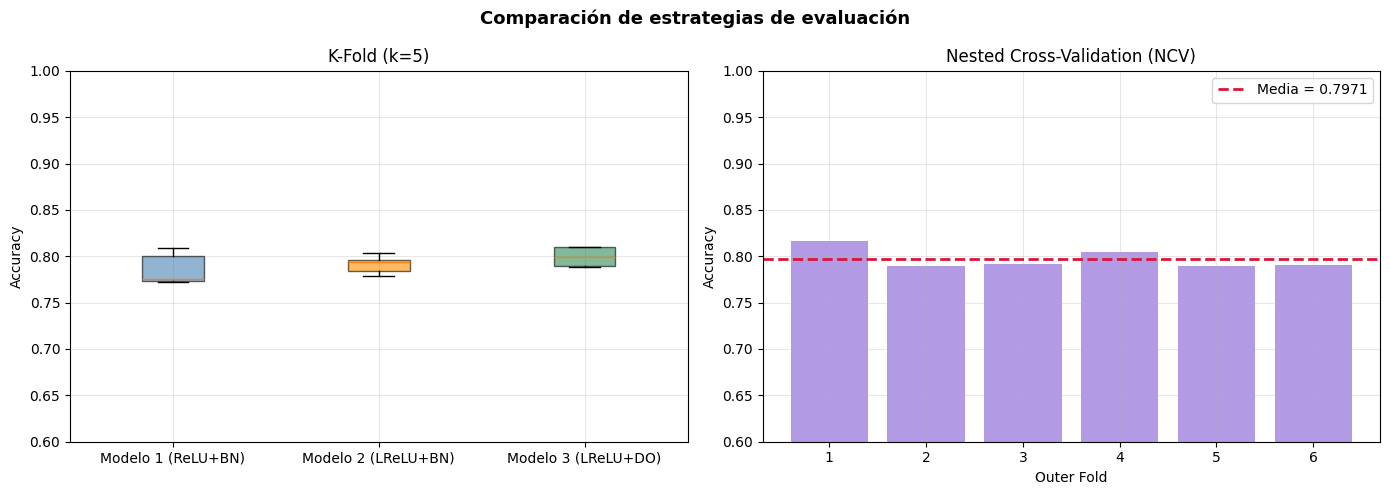

In [303]:
# ## Gráficas comparativas: K-Fold y NCV
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparación de estrategias de evaluación', fontsize=13, fontweight='bold')
 
# K-Fold boxplot
ax = axes[0]
names  = list(kfold_scores.keys())
values = [kfold_scores[n] for n in names]
bp = ax.boxplot(values, patch_artist=True, labels=names)
for patch, c in zip(bp['boxes'], ['steelblue', 'darkorange', 'seagreen']):
    patch.set_facecolor(c); patch.set_alpha(0.6)
ax.set_title('K-Fold (k=5)'); ax.set_ylabel('Accuracy')
ax.set_ylim(0.60, 1.0); ax.grid(True, alpha=0.3)
 
# NCV barras
ax = axes[1]
ax.bar(range(1, len(ncv_scores)+1), ncv_scores, color='mediumpurple', alpha=0.7)
ax.axhline(np.mean(ncv_scores), color='crimson', linestyle='--', linewidth=2,
           label=f'Media = {np.mean(ncv_scores):.4f}')
ax.set_title('Nested Cross-Validation (NCV)')
ax.set_xlabel('Outer Fold'); ax.set_ylabel('Accuracy')
ax.set_ylim(0.60, 1.0); ax.legend(); ax.grid(True, alpha=0.3)
 
plt.tight_layout(); plt.show()

In [304]:
# ## Resumen final
 
_, acc_p1 = model_p1.evaluate(X_test, y_test, verbose=0)
_, acc_p2 = model_p2.evaluate(X_test, y_test, verbose=0)
_, acc_p3 = model_p3.evaluate(X_test, y_test, verbose=0)
 
resumen = pd.DataFrame({
    'Modelo': ['M1: ReLU + BN', 'M2: Leaky ReLU + BN', 'M3: Leaky ReLU + Dropout'],
    'Test Acc (70-20-10)': [acc_p1, acc_p2, acc_p3],
    'K-Fold mean':  [np.mean(kfold_scores[k]) for k in kfold_scores],
    'K-Fold std':   [np.std(kfold_scores[k])  for k in kfold_scores],
})
resumen['NCV mean'] = np.mean(ncv_scores)
resumen['NCV std']  = np.std(ncv_scores)
print(resumen.to_string(index=False))

                  Modelo  Test Acc (70-20-10)  K-Fold mean  K-Fold std  NCV mean  NCV std
           M1: ReLU + BN             0.789655     0.785888    0.015425  0.797059 0.010029
     M2: Leaky ReLU + BN             0.800000     0.791129    0.008779  0.797059 0.010029
M3: Leaky ReLU + Dropout             0.798851     0.799438    0.009299  0.797059 0.010029
